In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("spx_eod_202301.txt")
pd.set_option('display.max_columns', None)
df = df.sample(500)
df.head()

,[QUOTE_UNIXTIME],[QUOTE_READTIME],[QUOTE_DATE],[QUOTE_TIME_HOURS],[UNDERLYING_LAST],[EXPIRE_DATE],[EXPIRE_UNIX],[DTE],[C_DELTA],[C_GAMMA],[C_VEGA],[C_THETA],[C_RHO],[C_IV],[C_VOLUME],[C_LAST],[C_SIZE],[C_BID],[C_ASK],[STRIKE],[P_BID],[P_ASK],[P_SIZE],[P_LAST],[P_DELTA],[P_GAMMA],[P_VEGA],[P_THETA],[P_RHO],[P_IV],[P_VOLUME],[STRIKE_DISTANCE],[STRIKE_DISTANCE_PCT]
134427,1675112400,2023-01-30 16:00,2023-01-30,16.0,4018.18,2023-06-30,1688155200,150.96,0.68858,0.00073,9.12996,-0.86093,10.20193,0.189990,,0.00,11 x 11,309.9,313.9,3880.0,120.40,121.5,42 x 12,168.88,-0.32899,0.00073,9.29445,-0.48291,-5.09467,0.205320,3.000000,138.2,0.034
122998,1674853200,2023-01-27 16:00,2023-01-27,16.0,4070.02,2023-02-14,1676408400,18.00,0.69671,0.00202,3.21572,-1.77424,1.39316,0.186920,2.000000,119.90,95 x 35,116.8,119.7,3990.0,33.90,34.4,13 x 31,59.10,-0.30300,0.00203,3.21969,-1.55378,-0.63545,0.187280,1.000000,80.0,0.020
56955,1673643600,2023-01-13 16:00,2023-01-13,16.0,3998.71,2023-03-17,1679083200,62.96,1.00000,0.00000,65.80788,0.00000,0.00000,0.000390,157.000000,1945.94,15 x 15,2100.6,2105.7,1900.0,0.25,0.4,119 x 2662,0.30,-0.00087,0.00000,0.06068,-0.02742,-0.00761,0.610220,100.000000,2098.7,0.525
141852,1675198800,2023-01-31 16:00,2023-01-31,16.0,4077.16,2023-06-16,1686945600,135.96,0.01101,0.00004,0.72781,-0.04157,0.16131,0.144280,9.000000,1.27,1220 x 185,1.2,1.4,5075.0,926.80,943.2,10 x 10,0.00,-1.00000,0.00000,0.00000,0.00000,0.00000,,,997.8,0.245
87111,1674248400,2023-01-20 16:00,2023-01-20,16.0,3971.98,2023-03-03,1677877200,42.00,0.88314,0.00066,2.64318,-0.89707,3.70474,0.214140,,0.00,100 x 100,337.4,343.9,3660.0,19.00,19.4,59 x 105,22.50,-0.12326,0.00071,2.78247,-0.68218,-0.58917,0.223340,7.000000,312.0,0.079


In [3]:
# drops columns that we may not need
df = df.drop(columns=["[QUOTE_UNIXTIME]", " [QUOTE_READTIME]", " [QUOTE_DATE]", " [EXPIRE_DATE]", " [EXPIRE_UNIX]"])

In [4]:
# rename for easier use in future
df = df.rename(columns={
    ' [QUOTE_TIME_HOURS]' : "Quote_Time_Hours",
    ' [UNDERLYING_LAST]' : "Underlying_Last",
    ' [DTE]' : "DTE", 
    ' [C_DELTA]' : "C_Delta",
    ' [C_GAMMA]' : "C_Gamma", 
    ' [C_VEGA]' : "C_Vega", 
    ' [C_THETA]' : "C_Theta",
    ' [C_RHO]' : "C_Rho", 
    ' [C_IV]' : "C_IV",
    ' [C_VOLUME]' : "C_Volume",
    ' [C_LAST]' : "C_Last", 
    ' [C_SIZE]' : "C_Size", 
    ' [C_BID]' : "C_Bid", 
    ' [C_ASK]' : "C_Ask",
    ' [STRIKE]' : "Strike", 
    ' [P_BID]' : "P_Bid",
    ' [P_ASK]' : "P_Ask",
    ' [P_SIZE]' : "P_Size", 
    ' [P_LAST]' : "P_Last",
    ' [P_DELTA]' : "P_Delta", 
    ' [P_GAMMA]' : "P_Gamma", 
    ' [P_VEGA]' : "P_Vega", 
    ' [P_THETA]' : "P_Theta", 
    ' [P_RHO]' : "P_Rho",
    ' [P_IV]' : "P_IV", 
    ' [P_VOLUME]' : "P_Volume", 
    ' [STRIKE_DISTANCE]' : "Strike_Distance",
    ' [STRIKE_DISTANCE_PCT]' : "Strike_Distance_PCT"
})


In [5]:
# turn " " in implied volatility columns into missing values and then drop
df["P_IV"] = df["P_IV"].replace(" ", np.nan)
df["C_IV"] = df["C_IV"].replace(" ", np.nan)
df = df.dropna(subset=["C_IV", "P_IV"])


In [6]:
# convert string into float
df["P_IV"] = df["P_IV"].astype(float)
df["C_IV"] = df["C_IV"].astype(float)

In [7]:
# create new columns, separate the size into bid and ask, convert to int
df["C_Bid_Size"] = df["C_Size"].str.split("x").str.get(0).astype(float)
df["C_Ask_Size"] = df["C_Size"].str.split("x").str.get(1).astype(float)
df["P_Bid_Size"] = df["P_Size"].str.split("x").str.get(0).astype(float)
df["P_Ask_Size"] = df["P_Size"].str.split("x").str.get(1).astype(float)

In [8]:
# since new columns were made we can drop original C_Size and P_Size
df = df.drop(columns = ["C_Size", "P_Size"])

In [9]:
# replace missing with zero and convert to float value 
df["C_Volume"] = df["C_Volume"].replace(" ", 0)
df["P_Volume"] = df["P_Volume"].replace(" ", 0)
df["C_Volume"] = df["C_Volume"].astype(float)
df["P_Volume"] = df["P_Volume"].astype(float)

In [10]:
call_X = df[["Quote_Time_Hours", "Underlying_Last", "DTE", "C_Volume", "C_Last", "C_Bid", "C_Ask", "Strike", "C_Bid_Size", "C_Ask_Size"]]
call_y = df["C_IV"]
call_X_train, call_X_test, call_y_train, call_y_test = train_test_split(
    call_X,
    call_y,
    test_size=0.25,
    random_state=42
)
call_rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
call_rf.fit(call_X_train, call_y_train)
call_y_test_pred = call_rf.predict(call_X_test)
df["Predicted_C_IV"] = call_rf.predict(call_X)
df
print("MAE:", mean_absolute_error(call_y_test, call_y_test_pred))
print("R²:", r2_score(call_y_test, call_y_test_pred))

MAE: 0.07637320416666664
R²: 0.24737121691644592


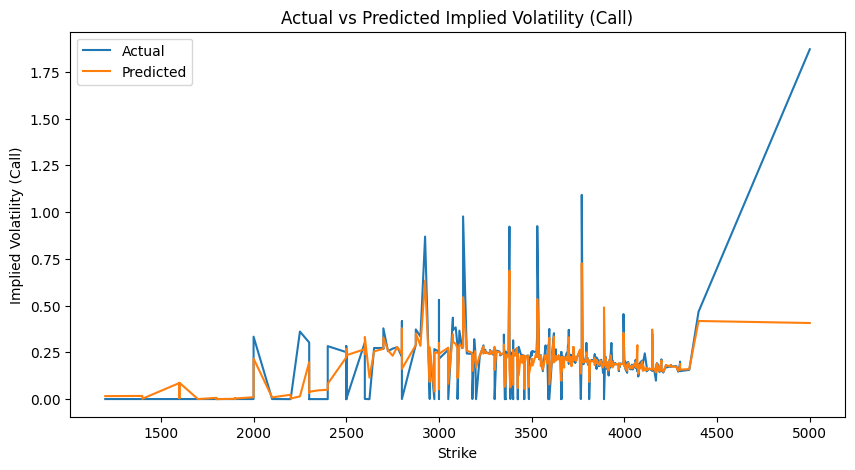

In [11]:
df_sorted = df.sort_values("Strike")

plt.figure(figsize=(10, 5))
plt.plot(df_sorted["Strike"], df_sorted["C_IV"], label="Actual")
plt.plot(df_sorted["Strike"], df_sorted["Predicted_C_IV"], label="Predicted")
plt.xlabel("Strike")
plt.ylabel("Implied Volatility (Call)")
plt.title("Actual vs Predicted Implied Volatility (Call)")
plt.legend()
plt.show()

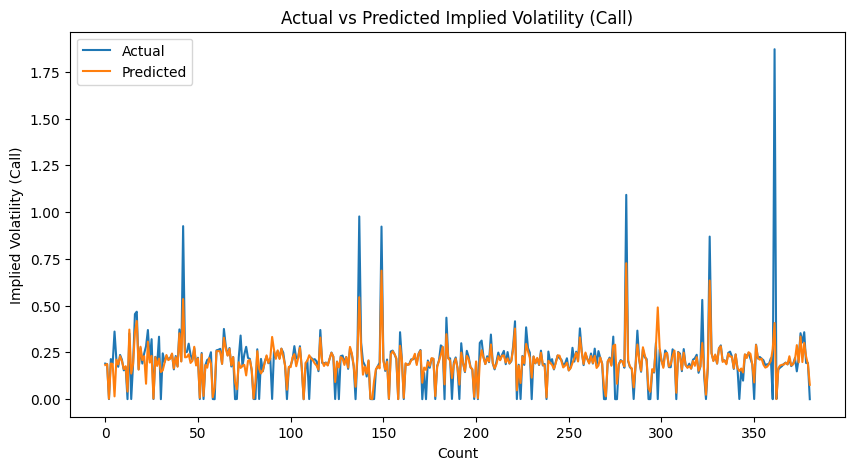

In [12]:
x = range(len(df))
plt.figure(figsize=(10, 5))
plt.plot(x, df["C_IV"], label="Actual")
plt.plot(x, df["Predicted_C_IV"], label="Predicted")
plt.xlabel("Count")
plt.ylabel("Implied Volatility (Call)")
plt.title("Actual vs Predicted Implied Volatility (Call)")
plt.legend()
plt.show()

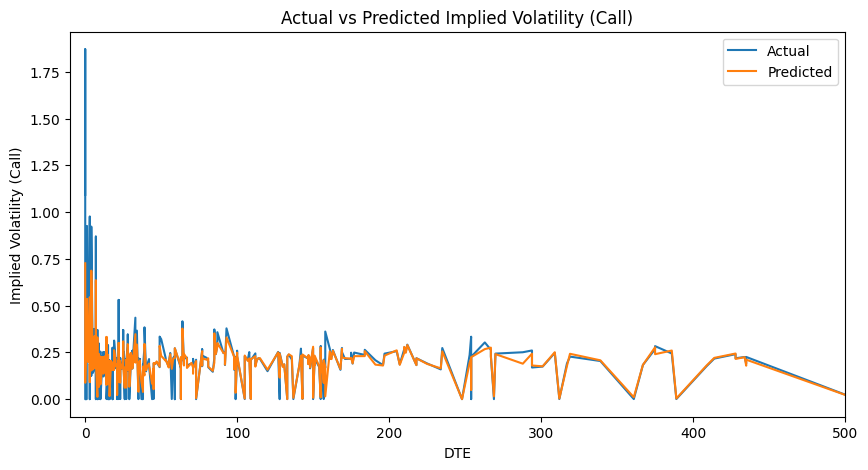

In [13]:
df_sorted = df.sort_values("DTE")
plt.figure(figsize=(10, 5))
plt.plot(df_sorted["DTE"], df_sorted["C_IV"], label="Actual")
plt.plot(df_sorted["DTE"], df_sorted["Predicted_C_IV"], label="Predicted")
plt.xlabel("DTE")
plt.ylabel("Implied Volatility (Call)")
plt.title("Actual vs Predicted Implied Volatility (Call)")
plt.xlim(-10, 500)
plt.legend()
plt.show()

In [18]:
put_X = df[["Quote_Time_Hours", "Underlying_Last", "DTE", "P_Volume", "P_Last", "P_Bid", "P_Ask", "Strike", "P_Bid_Size", "P_Ask_Size"]]
put_y = df["P_IV"]
put_X_train, put_X_test, put_y_train, put_y_test = train_test_split(
    put_X,
    put_y,
    test_size=0.25,
    random_state=42
)
put_rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
put_rf.fit(put_X_train, put_y_train)
put_y_test_pred = put_rf.predict(put_X_test)
df["Predicted_P_IV"] = put_rf.predict(put_X)
df
print("MAE:", mean_absolute_error(put_y_test, put_y_test_pred))
print("R²:", r2_score(put_y_test, put_y_test_pred))

MAE: 0.06511264062500009
R²: -2.75881587914316


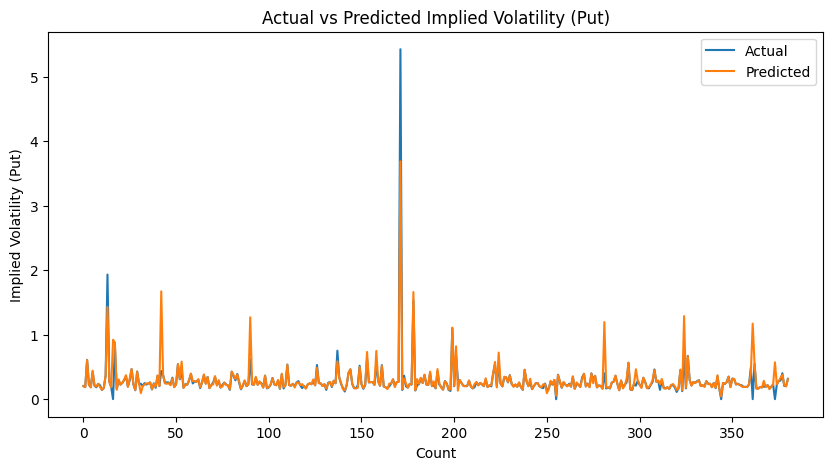

In [19]:
x = range(len(df))
plt.figure(figsize=(10, 5))
plt.plot(x, df["P_IV"], label="Actual")
plt.plot(x, df["Predicted_P_IV"], label="Predicted")
plt.xlabel("Count")
plt.ylabel("Implied Volatility (Put)")
plt.title("Actual vs Predicted Implied Volatility (Put)")
plt.legend()

plt.show()

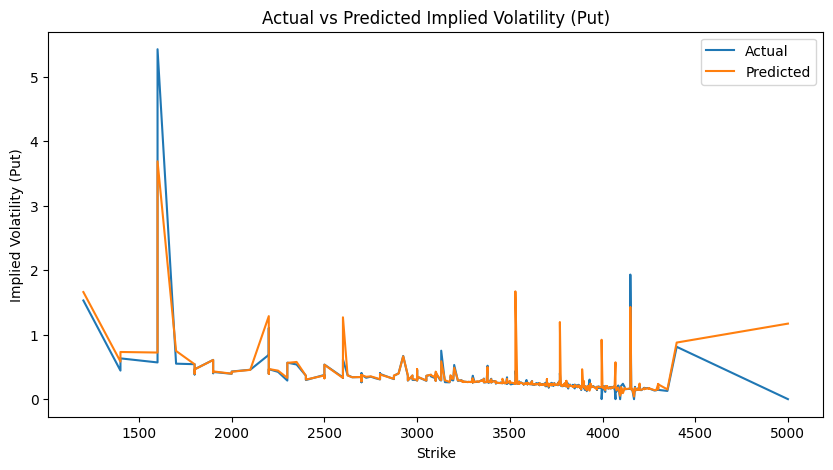

In [20]:
df_sorted = df.sort_values("Strike")

plt.figure(figsize=(10, 5))
plt.plot(df_sorted["Strike"], df_sorted["P_IV"], label="Actual")
plt.plot(df_sorted["Strike"], df_sorted["Predicted_P_IV"], label="Predicted")
plt.xlabel("Strike")
plt.ylabel("Implied Volatility (Put)")
plt.title("Actual vs Predicted Implied Volatility (Put)")
plt.legend()
plt.show()

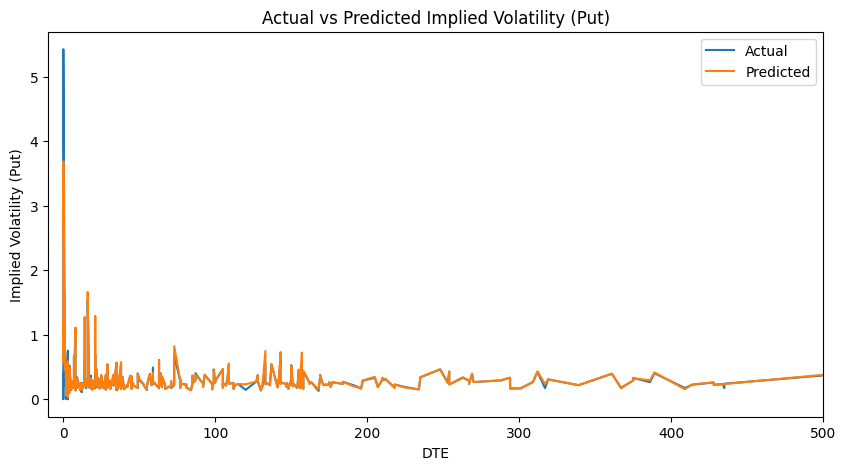

In [21]:
df_sorted = df.sort_values("DTE")
plt.figure(figsize=(10, 5))
plt.plot(df_sorted["DTE"], df_sorted["P_IV"], label="Actual")
plt.plot(df_sorted["DTE"], df_sorted["Predicted_P_IV"], label="Predicted")
plt.xlabel("DTE")
plt.ylabel("Implied Volatility (Put)")
plt.title("Actual vs Predicted Implied Volatility (Put)")
plt.xlim(-10, 500)
plt.legend()
plt.show()

In [22]:
df.head()

,Quote_Time_Hours,Underlying_Last,DTE,C_Delta,C_Gamma,C_Vega,C_Theta,C_Rho,C_IV,C_Volume,C_Last,C_Bid,C_Ask,Strike,P_Bid,P_Ask,P_Last,P_Delta,P_Gamma,P_Vega,P_Theta,P_Rho,P_IV,P_Volume,Strike_Distance,Strike_Distance_PCT,C_Bid_Size,C_Ask_Size,P_Bid_Size,P_Ask_Size,Predicted_C_IV,Predicted_P_IV
134427,16.0,4018.18,150.96,0.68858,0.00073,9.12996,-0.86093,10.20193,0.18999,0.0,0.00,309.9,313.9,3880.0,120.40,121.5,168.88,-0.32899,0.00073,9.29445,-0.48291,-5.09467,0.20532,3.0,138.2,0.034,11.0,11.0,42.0,12.0,0.182504,0.203116
122998,16.0,4070.02,18.00,0.69671,0.00202,3.21572,-1.77424,1.39316,0.18692,2.0,119.90,116.8,119.7,3990.0,33.90,34.4,59.10,-0.30300,0.00203,3.21969,-1.55378,-0.63545,0.18728,1.0,80.0,0.020,95.0,35.0,13.0,31.0,0.187479,0.189057
56955,16.0,3998.71,62.96,1.00000,0.00000,65.80788,0.00000,0.00000,0.00039,157.0,1945.94,2100.6,2105.7,1900.0,0.25,0.4,0.30,-0.00087,0.00000,0.06068,-0.02742,-0.00761,0.61022,100.0,2098.7,0.525,15.0,15.0,119.0,2662.0,0.001992,0.608702
87111,16.0,3971.98,42.00,0.88314,0.00066,2.64318,-0.89707,3.70474,0.21414,0.0,0.00,337.4,343.9,3660.0,19.00,19.4,22.50,-0.12326,0.00071,2.78247,-0.68218,-0.58917,0.22334,7.0,312.0,0.079,100.0,100.0,59.0,105.0,0.190158,0.226842
13783,16.0,3808.19,224.96,0.37281,0.00061,11.30791,-0.62641,7.94325,0.19092,2.0,165.50,134.9,136.3,4150.0,390.50,393.1,336.82,-0.70215,0.00093,9.63489,-0.23397,-8.90706,0.19000,1.0,341.8,0.090,10.0,34.0,14.0,14.0,0.188346,0.182265
